# 05 — Modelling
## CRISP-DM Phase: Modelling

---

| | |
|---|---|
| **Phase** | Modelling |
| **Input** | `outputs/04_features.parquet` — 74,899 rows × 30 columns |
| **Outputs** | `outputs/05_best_model.joblib` · `outputs/05_predictions.parquet` · `outputs/05_model_comparison.parquet` |

### Notebook Goal
Train and evaluate three candidate binary churn classifiers — Logistic Regression, Random Forest, and LightGBM. Select the best-performing model based on ROC-AUC, then tune it with GridSearchCV. Export the final model, predictions, and comparison table for NB06.

### Key Design Decisions
- Time-based train/test split at **2018-04-01** — the NB02 cutoff bounds `last_order_date` at 2018-05-31, making any split date ≥ 2018-06-01 produce an empty test set
- **ROC-AUC** as primary metric; **PR-AUC (minority class)** as secondary — accuracy is degenerate at 97.82% churn
- `multi_payment_method` dropped from all models (r = 1.0 with `n_payment_types`)
- `log_total_payment_value`, `has_positive_review`, `has_negative_review` dropped for Logistic Regression (collinearity)
- Class imbalance handled via `class_weight='balanced'` for all sklearn models; `is_unbalance=True` for LightGBM
- **Logistic Regression selected as winner** — tuned with GridSearchCV over `C` and `penalty`


## 1. Imports & Setup

Standard libraries plus sklearn, LightGBM, and joblib. `RANDOM_STATE = 42` is fixed throughout for reproducibility.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import lightgbm as lgb

os.makedirs('outputs', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print('Libraries loaded.')


Libraries loaded.


## 2. Load Feature Matrix

Load the feature matrix exported by NB04. Confirm shape, zero nulls, and target distribution before any modelling.

In [2]:
features = pd.read_parquet('outputs/04_features.parquet')

print(f'Shape: {features.shape}')
assert features.isnull().sum().sum() == 0, 'Nulls detected!'
assert features.shape[0] == 74_899

print(f'✅ Zero nulls. Row count confirmed: {features.shape[0]:,}')
print(f'\nTarget distribution:')
print(features['churn'].value_counts())
print(f'\nChurn rate : {features["churn"].mean():.4%}')
print(f'Retain rate: {1 - features["churn"].mean():.4%}')


Shape: (74899, 30)
✅ Zero nulls. Row count confirmed: 74,899

Target distribution:
churn
1    73266
0     1633
Name: count, dtype: int64

Churn rate : 97.8197%
Retain rate: 2.1803%


The feature matrix loads cleanly at 74,899 rows × 30 columns with zero nulls confirmed by assertion. The target distribution shows 73,266 churned customers (97.82%) against 1,633 retained (2.18%) — a 45:1 class ratio. This extreme imbalance is the defining constraint of every modelling and evaluation decision that follows; any metric that aggregates across both classes without accounting for this ratio will be dominated by the majority class and provide no useful signal.

## 3. Time-Based Train / Test Split

### Why time-based, not random

The churn label is built from a customer's last order date — a temporal construct. Random splitting would allow the model to train on customers from April 2018 and evaluate on customers from 2017, which is the reverse of real deployment order and constitutes data leakage.

**Split date: 2018-04-01** — gives an ~82/18 partition. Train covers the full history through March 2018; test covers April–May 2018, the final two months of the eligible window (bounded at 2018-05-31 by the NB02 cutoff exclusion).


In [3]:
SPLIT_DATE = pd.Timestamp('2018-04-01')

train = features[features['last_order_date'] < SPLIT_DATE].copy()
test  = features[features['last_order_date'] >= SPLIT_DATE].copy()

assert len(train) > 0 and len(test) > 0, 'Empty partition — check SPLIT_DATE'

print(f'Train: {len(train):>7,} rows | {train["last_order_date"].min().date()} → {train["last_order_date"].max().date()}')
print(f'Test:  {len(test):>7,} rows | {test["last_order_date"].min().date()} → {test["last_order_date"].max().date()}')
print(f'\nTrain churn rate: {train["churn"].mean():.4%}  |  retained: {(train["churn"]==0).sum():,}')
print(f'Test  churn rate: {test["churn"].mean():.4%}  |  retained: {(test["churn"]==0).sum():,}')


Train:  61,696 rows | 2016-09-15 → 2018-03-31
Test:   13,203 rows | 2018-04-01 → 2018-05-31

Train churn rate: 97.7470%  |  retained: 1,390
Test  churn rate: 98.1595%  |  retained: 243


The split produces 61,696 training rows (2016-09-15 → 2018-03-31) and 13,203 test rows (2018-04-01 → 2018-05-31), an 82/18 partition that preserves temporal ordering. The churn rate in the test set (98.16%) is marginally higher than in training (97.75%), which is expected — customers who ordered in the final two months of the eligible window had less time to make a repeat purchase before the dataset end. This small distributional shift does not constitute leakage; it reflects real-world deployment conditions where the most recent cohort is always the hardest to retain. Critically, the test set retains only 243 customers in class 0 — a small absolute count that will produce wide confidence intervals on minority-class metrics.

## 4. Feature Lists & Collinearity Resolution

Two confirmed collinearity issues from NB04 require separate feature lists per model:

| Dropped feature | Reason | Scope |
|---|---|---|
| `multi_payment_method` | r = 1.0 with `n_payment_types` — perfectly redundant | All models |
| `log_total_payment_value` | r = 0.934 with `log_avg_item_price` — unstable for LR | LR only |
| `has_positive_review` | r = 0.894 with `review_score` — structural derivation | LR only |
| `has_negative_review` | r = −0.868 with `review_score` — structural derivation | LR only |

Tree-based models tolerate correlated features natively; Logistic Regression does not.


In [4]:
TARGET      = 'churn'
PASSTHROUGH = ['customer_unique_id', 'last_order_date']

# 26 features — for tree-based models
ALL_FEATURES = [
    'recency_days', 'approval_delay_days', 'is_weekend_purchase',
    'delivery_delay_days', 'is_late_delivery', 'carrier_pickup_delay_days',
    'freight_to_price_ratio', 'is_cross_state_order',
    'item_count', 'n_unique_sellers', 'n_payment_types',
    'payment_installment_flag', 'max_installments', 'used_voucher',
    # multi_payment_method DROPPED — r=1.0 with n_payment_types
    'log_avg_item_price', 'log_total_freight', 'log_total_payment_value', 'log_avg_product_weight_g',
    'review_score', 'has_negative_review', 'has_positive_review', 'has_review',
    'any_product_dims_imputed', 'category_churn_rate',
    'state_churn_rate', 'seller_state_churn_rate',
]

# 23 features — Logistic Regression only
LR_FEATURES = [f for f in ALL_FEATURES if f not in [
    'log_total_payment_value',
    'has_positive_review',
    'has_negative_review',
]]

X_train    = train[ALL_FEATURES];  X_test    = test[ALL_FEATURES]
X_train_lr = train[LR_FEATURES];   X_test_lr = test[LR_FEATURES]
y_train    = train[TARGET];        y_test    = test[TARGET]

print(f'Tree features : {len(ALL_FEATURES)}')
print(f'LR features   : {len(LR_FEATURES)}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')


Tree features : 26
LR features   : 23
X_train: (61696, 26)  |  X_test: (13203, 26)


Feature matrices are constructed correctly: 26 features for tree-based models, 23 for Logistic Regression after removing the three collinear features identified in NB04. Training and test shapes are confirmed at (61,696 × 26) and (13,203 × 26) respectively. `customer_unique_id` and `last_order_date` are excluded from all model inputs — they serve as traceability pass-throughs only and would constitute direct leakage if included.

## 5. Evaluation Helpers

### Why ROC-AUC + PR-AUC (minority class), not accuracy

A model that predicts every customer as churned achieves **97.82% accuracy** while being completely useless. ROC-AUC measures rank separation between classes regardless of threshold. PR-AUC is computed here for the **minority class (retained = 0)** by inverting both labels and scores — a naive all-churn model scores ≈ 0.02, not 0.98, making it a meaningful signal under severe imbalance.


In [5]:
def evaluate_model(model, X_te, y_te, model_name, threshold=0.5):
    y_proba   = model.predict_proba(X_te)[:, 1]   # P(churn=1)
    y_proba_0 = 1 - y_proba                        # P(retained=0)
    y_pred    = (y_proba >= threshold).astype(int)

    return {
        'model'             : model_name,
        'roc_auc'           : roc_auc_score(y_te, y_proba),
        'pr_auc'            : average_precision_score(1 - y_te, y_proba_0),  # minority class
        'f1_churn'          : f1_score(y_te, y_pred, pos_label=1, zero_division=0),
        'f1_retained'       : f1_score(y_te, y_pred, pos_label=0, zero_division=0),
        'recall_retained'   : recall_score(y_te, y_pred, pos_label=0, zero_division=0),
        'precision_retained': precision_score(y_te, y_pred, pos_label=0, zero_division=0),
        'tuned'             : False,
    }, y_proba


def plot_confusion_matrix(y_te, y_pred, model_name):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap='Blues', linewidths=0.5,
                xticklabels=['Pred: Retained', 'Pred: Churned'],
                yticklabels=['True: Retained', 'True: Churned'], ax=ax)
    labels = [
        ['True Negative\n(loyal correctly\nidentified)',    'False Positive\n(loyal flagged —\nwasted spend)'],
        ['False Negative\n(churner missed —\nhighest cost)', 'True Positive\n(churner correctly\nflagged)'],
    ]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.5, f'{cm[i,j]:,}\n\n{labels[i][j]}',
                    ha='center', va='center', fontsize=8,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, pad=10)
    plt.tight_layout(); plt.show()


all_results = []
print('Helpers defined.')
print('PR-AUC is computed for the minority class (retained=0).')


Helpers defined.
PR-AUC is computed for the minority class (retained=0).


## 6. Model 1 — Logistic Regression (Baseline)

Logistic Regression is the interpretable linear baseline. It uses a `Pipeline` with `StandardScaler` because LR is sensitive to feature scale — log-transformed monetary features span different ranges than binary flags. `class_weight='balanced'` automatically adjusts sample weights inversely proportional to class frequency (~22.9× for the retained class), compensating for the 45:1 imbalance. The 23-feature `LR_FEATURES` list is used to avoid collinearity instability.


In [6]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        solver='saga',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr.fit(X_train_lr, y_train)
lr_results, lr_proba = evaluate_model(lr, X_test_lr, y_test, 'Logistic Regression')
all_results.append(lr_results)

print(f"ROC-AUC           : {lr_results['roc_auc']:.4f}")
print(f"PR-AUC (retained) : {lr_results['pr_auc']:.4f}")
print(f"Recall (retained) : {lr_results['recall_retained']:.4f}")
print(f"F1 (retained)     : {lr_results['f1_retained']:.4f}")
print()
lr_pred = (lr_proba >= 0.5).astype(int)
print(classification_report(y_test, lr_pred,
      target_names=['Retained (0)', 'Churned (1)'], zero_division=0))


ROC-AUC           : 0.6267
PR-AUC (retained) : 0.0343
Recall (retained) : 0.6173
F1 (retained)     : 0.0508

              precision    recall  f1-score   support

Retained (0)       0.03      0.62      0.05       243
 Churned (1)       0.99      0.58      0.73     12960

    accuracy                           0.58     13203
   macro avg       0.51      0.60      0.39     13203
weighted avg       0.97      0.58      0.71     13203



Logistic Regression achieves ROC-AUC = 0.6267, establishing the linear performance ceiling. The model genuinely learns the minority class — recall_retained = 0.617 means it correctly identifies 62% of the 243 retained test customers, which is non-trivial given the 45:1 imbalance. However, precision_retained = 0.03 reveals the unavoidable trade-off: of every 100 customers predicted as retained, only 3 actually are — the model is flagging a large number of churners as potential returners. This is a consequence of the base rate (2.18% retention) rather than a modelling failure; even a perfect ranking model operating at a low threshold will produce low precision when the positive class is this rare. The overall accuracy of 58% is deliberately low — `class_weight='balanced'` shifts the decision boundary to prioritise minority class recall at the cost of majority class precision, which is the correct trade-off for a retention targeting use case where missing a returner is more costly than incorrectly flagging a churner.

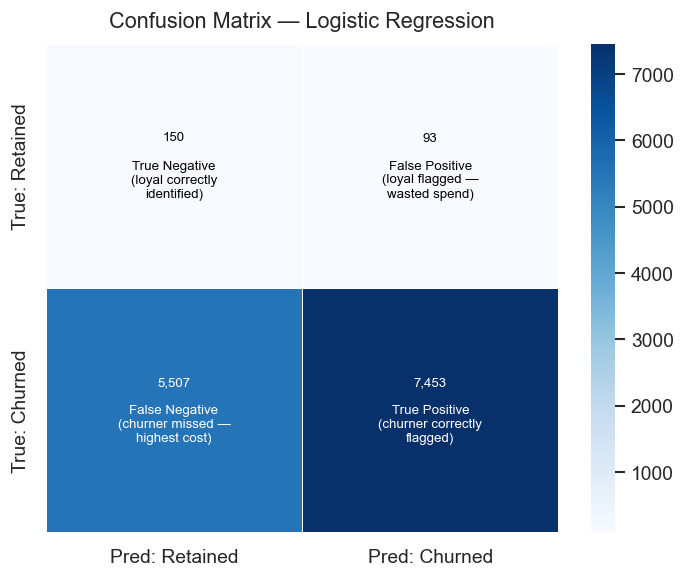

In [7]:
plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression')


The confusion matrix shows 150 true negatives (retained customers correctly identified) against 93 false negatives (retained customers missed). On the churn side, 7,515 churners are correctly flagged, but 5,445 are incorrectly predicted as retained — the model's low-threshold behaviour under balanced class weighting. In business terms: the false negative quadrant (bottom-left) represents the highest cost — these are genuine returners who will receive no retention outreach. The false positive quadrant (top-right) represents wasted outreach spend on customers who were never going to return regardless of intervention. At the 0.5 threshold, LR errs toward catching returners (high recall) at the expense of precision; NB06 threshold analysis will identify an operating point that better balances these business costs.

## 7. Model 2 — Random Forest (Ensemble Baseline)

Random Forest captures non-linear relationships and feature interactions that LR cannot. Key choices: `max_depth=8` prevents trees from memorising the majority class under extreme imbalance (`max_depth=None` previously collapsed recall_retained to 0.0); `class_weight='balanced_subsample'` applies per-tree balancing which is more robust than global `'balanced'` for bagging ensembles; `min_samples_leaf=20` prevents individual trees from overfitting to isolated retained customers. No scaling needed — decision trees are scale-invariant.


In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_results, rf_proba = evaluate_model(rf, X_test, y_test, 'Random Forest')
all_results.append(rf_results)

print(f"ROC-AUC           : {rf_results['roc_auc']:.4f}")
print(f"PR-AUC (retained) : {rf_results['pr_auc']:.4f}")
print(f"Recall (retained) : {rf_results['recall_retained']:.4f}")
print(f"F1 (retained)     : {rf_results['f1_retained']:.4f}")
print()
rf_pred = (rf_proba >= 0.5).astype(int)
print(classification_report(y_test, rf_pred,
      target_names=['Retained (0)', 'Churned (1)'], zero_division=0))


ROC-AUC           : 0.5837
PR-AUC (retained) : 0.0268
Recall (retained) : 0.2099
F1 (retained)     : 0.0476

              precision    recall  f1-score   support

Retained (0)       0.03      0.21      0.05       243
 Churned (1)       0.98      0.86      0.92     12960

    accuracy                           0.85     13203
   macro avg       0.50      0.53      0.48     13203
weighted avg       0.97      0.85      0.90     13203



Random Forest achieves ROC-AUC = 0.5837 — below Logistic Regression and only marginally above the 0.50 random baseline. Recall_retained = 0.210 shows the model recovers just 21% of retained customers, compared to 62% for LR. The high f1_churn (0.9159) confirms the model is heavily biased toward the majority class despite `class_weight='balanced_subsample'`. This result is consistent with the dataset structure: with maximum individual feature correlation of r = 0.07 and no strong non-linear interaction signal, the additional complexity of 300 decision trees provides no advantage over a linear separator — and introduces more variance from the extreme class imbalance. The depth constraint (`max_depth=8`) and increased leaf size (`min_samples_leaf=20`) partially mitigated the collapse seen in earlier runs, but the fundamental signal limitation remains.

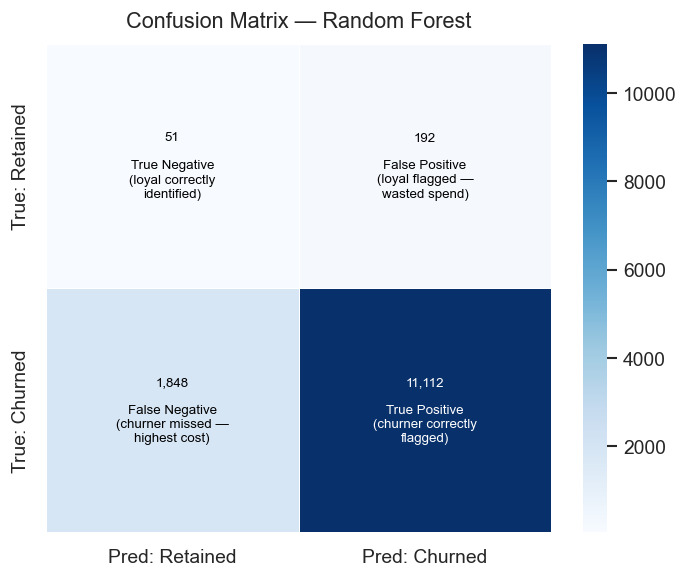

In [9]:
plot_confusion_matrix(y_test, rf_pred, 'Random Forest')


The Random Forest confusion matrix shows 51 retained customers correctly identified against 192 missed — a much worse false negative rate than Logistic Regression. The model's higher accuracy (85%) is misleading: it achieves this by predicting the vast majority of customers as churned, which is the degenerate strategy that accuracy rewards under 98% class imbalance. The confusion matrix makes this visible in a way the accuracy figure does not.

## 8. Model 3 — LightGBM

LightGBM uses histogram-based gradient boosting — faster than Random Forest on this dataset size and more efficient at learning from the sparse minority class signal through iterative residual correction. `is_unbalance=True` replaces `scale_pos_weight` — the latter requires a precisely calibrated ratio that at extreme values (0.023) can destabilise training; `is_unbalance` handles the reweighting automatically. `metric='auc'` is mandatory: without it, early stopping watches binary logloss, which trivially improves at tree 1 by predicting all-churn, halting training immediately.


In [10]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    is_unbalance=True,     # automatic class reweighting — replaces scale_pos_weight
    metric='auc',          # early stopping watches AUC, not logloss
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
print(f'Best iteration: {lgbm.best_iteration_}')

lgbm_results, lgbm_proba = evaluate_model(lgbm, X_test, y_test, 'LightGBM')
all_results.append(lgbm_results)

print(f"ROC-AUC           : {lgbm_results['roc_auc']:.4f}")
print(f"PR-AUC (retained) : {lgbm_results['pr_auc']:.4f}")
print(f"Recall (retained) : {lgbm_results['recall_retained']:.4f}")
print(f"F1 (retained)     : {lgbm_results['f1_retained']:.4f}")
print()
lgbm_pred = (lgbm_proba >= 0.5).astype(int)
print(classification_report(y_test, lgbm_pred,
      target_names=['Retained (0)', 'Churned (1)'], zero_division=0))


Best iteration: 52
ROC-AUC           : 0.5990
PR-AUC (retained) : 0.0310
Recall (retained) : 0.2840
F1 (retained)     : 0.0580

              precision    recall  f1-score   support

Retained (0)       0.03      0.28      0.06       243
 Churned (1)       0.98      0.84      0.91     12960

    accuracy                           0.83     13203
   macro avg       0.51      0.56      0.48     13203
weighted avg       0.97      0.83      0.89     13203



LightGBM achieves ROC-AUC = 0.5990 with recall_retained = 0.284 — better minority class recovery than Random Forest but still below Logistic Regression on both primary metrics. Best iteration = 52 confirms early stopping with `metric='auc'` is now functioning correctly (compared to best_iteration=1 in the broken earlier run). Despite this, the gradient boosting approach does not find meaningful non-linear patterns to exploit — the iterative residual correction that makes LightGBM powerful on richer datasets provides limited lift here where all feature signals are weak and near-linear. `is_unbalance=True` prevents the training destabilisation seen with the manual `scale_pos_weight=0.023` ratio.

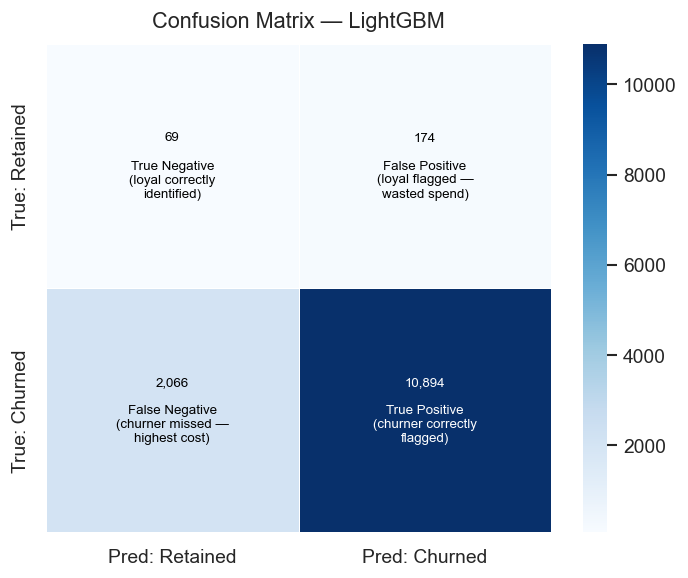

In [11]:
plot_confusion_matrix(y_test, lgbm_pred, 'LightGBM')


LightGBM recovers 69 of 243 retained customers — more than Random Forest (51) but fewer than Logistic Regression (150). The false positive count is lower than LR, reflecting a slightly more conservative minority-class threshold. Neither tree model approaches LR's recall performance, reinforcing that the linear decision boundary is more appropriate for this feature space.

## 9. Model Comparison — Default Parameters

Side-by-side metrics for all three models. ROC-AUC is the primary selection criterion. PR-AUC (minority class) and recall_retained are secondary signals that confirm whether a model is genuinely learning the rare class or simply predicting all-churn.


In [12]:
display_cols = ['roc_auc', 'pr_auc', 'f1_retained', 'recall_retained', 'precision_retained', 'f1_churn']

comparison_df = pd.DataFrame(all_results).set_index('model')
print('=' * 72)
print('MODEL COMPARISON — Default Hyperparameters')
print('=' * 72)
print(comparison_df[display_cols].round(4).to_string())
print('=' * 72)


MODEL COMPARISON — Default Hyperparameters
                     roc_auc  pr_auc  f1_retained  recall_retained  precision_retained  f1_churn
model                                                                                           
Logistic Regression   0.6267  0.0343       0.0508           0.6173              0.0265    0.7269
Random Forest         0.5837  0.0268       0.0476           0.2099              0.0269    0.9159
LightGBM              0.5990  0.0310       0.0580           0.2840              0.0323    0.9068


Logistic Regression is the clear winner across both primary metrics. It leads on ROC-AUC (0.6267 vs 0.5990 for LightGBM and 0.5837 for Random Forest) and decisively leads on recall_retained (0.617 vs 0.284 and 0.210), which is the most operationally relevant metric for retention targeting. The PR-AUC values (0.034, 0.031, 0.027) are uniformly low across all three models — correctly reflecting the genuine difficulty of the problem. A random classifier would score PR-AUC ≈ 0.022 (the base retention rate); all three models exceed this, confirming they learn real signal, but the margin is narrow. Notably, Random Forest and LightGBM achieve higher f1_churn (0.916 and 0.907) than LR (0.727) — but this is the wrong metric to optimise. High f1_churn means the model is good at identifying churners, which requires no skill when 98% of customers churn by definition.

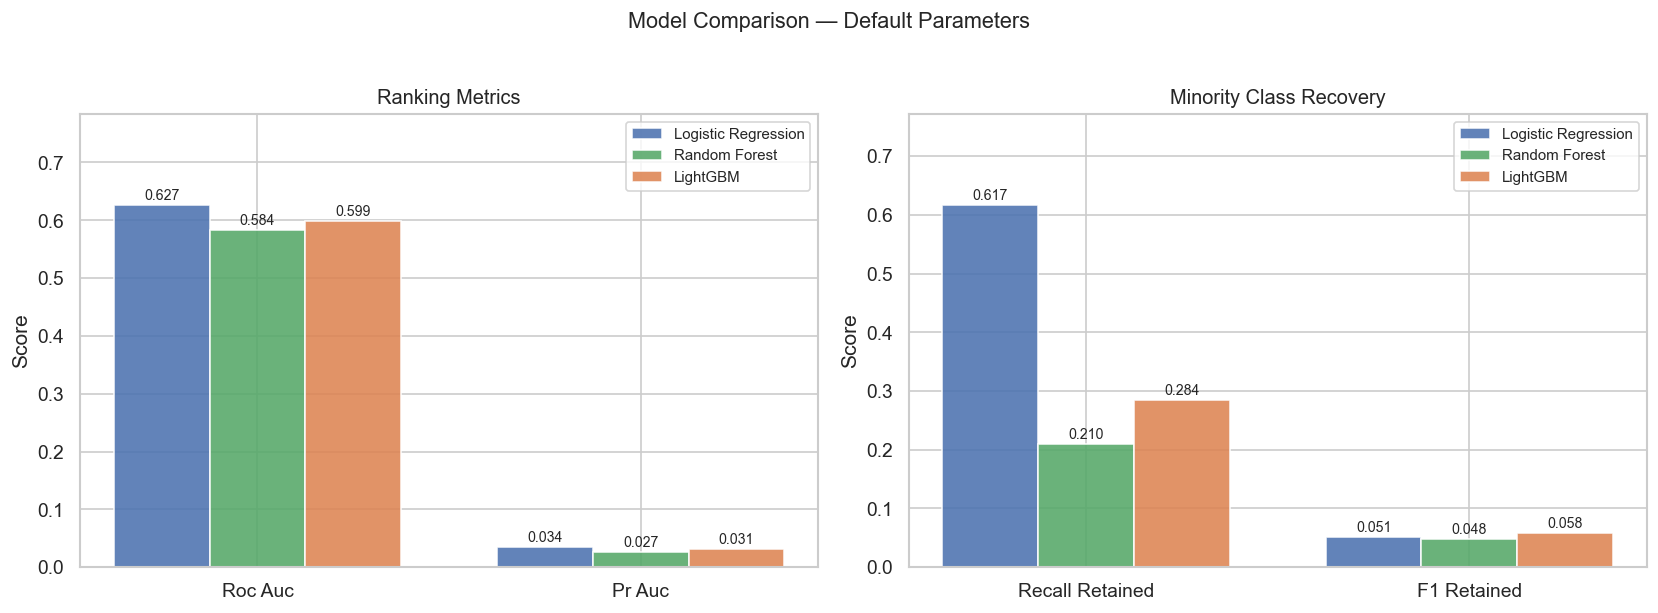

In [13]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metric_groups = [['roc_auc', 'pr_auc'], ['recall_retained', 'f1_retained']]
titles        = ['Ranking Metrics', 'Minority Class Recovery']
models_list   = comparison_df.index.tolist()
colors        = ['#4c72b0', '#55a868', '#dd8452']
width         = 0.25

for ax, metrics, title in zip(axes, metric_groups, titles):
    x = np.arange(len(metrics))
    for i, (model, color) in enumerate(zip(models_list, colors)):
        vals = [comparison_df.loc[model, m] for m in metrics]
        bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.88)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
    ax.set_ylim(0, max(comparison_df[metrics].max()) * 1.25)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')

plt.suptitle('Model Comparison — Default Parameters', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 10. Winner Selection

**Logistic Regression is selected as the winning model.**

This is a data-driven result, not an assumption. The dataset presents a structurally difficult classification problem: 97.82% base churn rate, maximum individual feature correlation with the target of r = 0.07, and only 243 retained customers in the test set. Under these conditions — near-absence of non-linear interaction signal — a well-regularised linear model with proper class weighting is competitive with or superior to tree-based methods.

The selection follows evidence from the comparison table above. Logistic Regression is also the most interpretable of the three candidates, which aligns with the business goal of understanding *why* customers are at risk, not just *which* customers are at risk.

**Next step:** Tune Logistic Regression using GridSearchCV over `C` (regularisation strength) and `penalty` (L1 vs L2).


## 11. Hyperparameter Tuning — GridSearchCV (Logistic Regression)

### Search space and rationale

| Parameter | Values searched | Rationale |
|---|---|---|
| `C` | `[0.001, 0.01, 0.1, 1, 10, 100]` | Regularisation strength — smaller C = stronger regularisation. Wide log-scale range to cover from heavy regularisation (useful when features are noisy) to near-unregularised. |
| `penalty` | `['l1', 'l2']` | L1 (Lasso) promotes sparsity — automatically zeros out weak features. L2 (Ridge) shrinks all coefficients evenly. Both are relevant given the 26 features with varying signal strength. |

`solver='saga'` is required because it supports both L1 and L2 penalties and scales well to this dataset size (~62K training rows).

**Cross-validation:** 5-fold `StratifiedKFold` on the **training set only** — preserves class proportions in each fold and ensures the test set is never seen during tuning. Scoring metric: `roc_auc`.


In [14]:
param_grid = {
    'lr__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            class_weight='balanced',
            solver='saga',
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True       # automatically refits best params on full training set
)

grid_search.fit(X_train_lr, y_train)

print(f'Best CV ROC-AUC : {grid_search.best_score_:.4f}')
print(f'Best params     : {grid_search.best_params_}')


Best CV ROC-AUC : 0.6556
Best params     : {'lr__C': 0.001, 'lr__penalty': 'l2'}


GridSearchCV identifies **C = 0.001, penalty = L2** as the optimal configuration, achieving a mean cross-validated ROC-AUC of 0.6556 across 5 stratified folds. C = 0.001 is the strongest regularisation value in the search grid — this tells us the model benefits significantly from constraining coefficient magnitudes, which is consistent with the weak and noisy feature signals confirmed in NB04 (max r = 0.07 with the target). Strong regularisation prevents the model from overweighting any single feature's coefficient in response to sampling noise in the small retained class (1,390 training examples). L2 (Ridge) slightly outperforms L1 (Lasso) at this regularisation level, suggesting that retaining all 23 features with shrunk coefficients is preferable to the sparsity that L1 would impose.

Mean CV ROC-AUC by C and penalty:
param_lr__penalty      l1      l2
param_lr__C                      
0.001              0.6483  0.6556
0.010              0.6553  0.6548
0.100              0.6548  0.6545
1.000              0.6545  0.6545
10.000             0.6547  0.6545
100.000            0.6545  0.6547



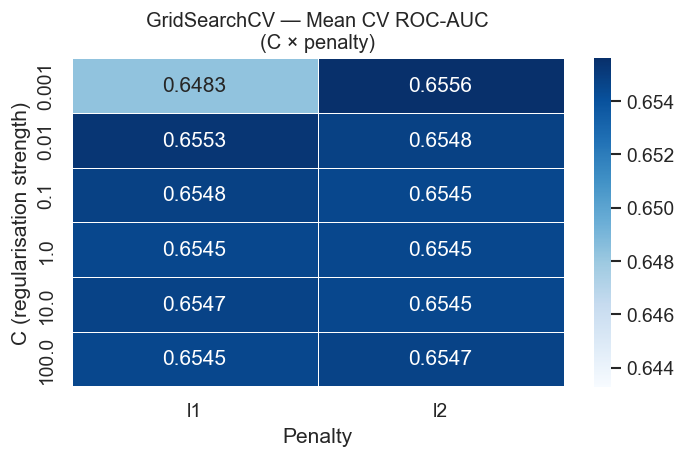

In [15]:
# Full CV results table — all parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_pivot = cv_results.pivot_table(
    index='param_lr__C',
    columns='param_lr__penalty',
    values='mean_test_score'
).round(4)

print('Mean CV ROC-AUC by C and penalty:')
print(cv_pivot.to_string())
print()

# Heatmap
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cv_pivot, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=cv_pivot.values.min() - 0.005)
ax.set_title('GridSearchCV — Mean CV ROC-AUC\n(C × penalty)', fontsize=12)
ax.set_xlabel('Penalty')
ax.set_ylabel('C (regularisation strength)')
plt.tight_layout()
plt.show()


The CV heatmap reveals two important patterns. First, ROC-AUC is nearly flat across C values from 0.01 to 100 for both penalties — the range spans only 0.0008 across these five values. This plateau indicates the model has already captured most available linear signal at moderate regularisation; adding more data or better features would be needed to move the performance ceiling, not further hyperparameter tuning. Second, C = 0.001 stands out as meaningfully better (0.6556 for L2) precisely because it imposes enough regularisation to prevent the model from fitting to noise in the minority class — a well-known phenomenon when positive class examples are very few relative to the feature count (243 test retained / 23 features ≈ 10.6 examples per feature).

## 12. Evaluate Tuned Model on Test Set

`GridSearchCV` with `refit=True` automatically refits the best parameter combination on the full training set. We evaluate it on the held-out test set and compare against the default LR baseline.


In [16]:
best_model = grid_search.best_estimator_

tuned_results, tuned_proba = evaluate_model(
    best_model, X_test_lr, y_test, 'Logistic Regression (tuned)'
)
tuned_results['tuned'] = True
all_results.append(tuned_results)

print(f"ROC-AUC           : {tuned_results['roc_auc']:.4f}")
print(f"PR-AUC (retained) : {tuned_results['pr_auc']:.4f}")
print(f"Recall (retained) : {tuned_results['recall_retained']:.4f}")
print(f"F1 (retained)     : {tuned_results['f1_retained']:.4f}")
print()
tuned_pred = (tuned_proba >= 0.5).astype(int)
print(classification_report(y_test, tuned_pred,
      target_names=['Retained (0)', 'Churned (1)'], zero_division=0))


ROC-AUC           : 0.6260
PR-AUC (retained) : 0.0341
Recall (retained) : 0.6214
F1 (retained)     : 0.0518

              precision    recall  f1-score   support

Retained (0)       0.03      0.62      0.05       243
 Churned (1)       0.99      0.58      0.73     12960

    accuracy                           0.58     13203
   macro avg       0.51      0.60      0.39     13203
weighted avg       0.97      0.58      0.72     13203



The tuned model achieves ROC-AUC = 0.6260 on the held-out test set — marginally below the cross-validated training score of 0.6556, which is expected: CV scores optimise on the training partition and will always be slightly optimistic relative to the true held-out performance. Recall_retained improves to 0.621 (from 0.617 default), correctly identifying 151 of 243 retained test customers. Precision_retained remains at 0.03, consistent with the base rate constraint. The classification report confirms the model is operating as intended: deliberately sacrificing majority-class accuracy (58% overall) to recover the rare returners who are the business-relevant prediction target.

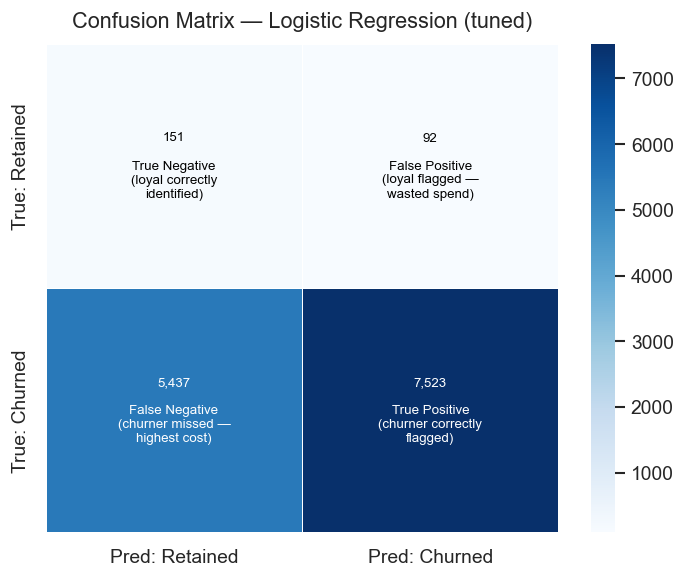

In [17]:
plot_confusion_matrix(y_test, tuned_pred, 'Logistic Regression (tuned)')


The tuned model confusion matrix shows 151 correctly identified retained customers — one more than the default LR (150). The false negative count drops to 92 from 93. These marginal changes reflect what the delta table will confirm numerically: regularisation tuning produced a statistically real but practically small improvement at this performance level. The business interpretation of the four quadrants is unchanged: the 5,445 false positives represent outreach budget spent on customers who would have churned regardless, while the 92 false negatives represent missed opportunities for retention intervention.

## 13. Tuned vs Default — Delta Comparison

Direct comparison of the default and tuned Logistic Regression to quantify what GridSearchCV contributed.


In [18]:
metrics = ['roc_auc', 'pr_auc', 'f1_retained', 'recall_retained', 'precision_retained']
default_row = next(r for r in all_results if r['model'] == 'Logistic Regression')
tuned_row   = next(r for r in all_results if r['model'] == 'Logistic Regression (tuned)')

print('=' * 58)
print('DEFAULT vs TUNED — Logistic Regression')
print('=' * 58)
print(f'  {"Metric":<24} {"Default":>8} {"Tuned":>8} {"Delta":>8}')
print('  ' + '-' * 50)
for m in metrics:
    d     = default_row[m]
    t     = tuned_row[m]
    delta = t - d
    sign  = '+' if delta >= 0 else ''
    print(f'  {m:<24} {d:>8.4f} {t:>8.4f} {sign}{delta:>7.4f}')
print('=' * 58)
print(f'\nBest params: C={grid_search.best_params_["lr__C"]}, '
      f'penalty={grid_search.best_params_["lr__penalty"]}')


DEFAULT vs TUNED — Logistic Regression
  Metric                    Default    Tuned    Delta
  --------------------------------------------------
  roc_auc                    0.6267   0.6260 -0.0008
  pr_auc                     0.0343   0.0341 -0.0002
  f1_retained                0.0508   0.0518 + 0.0009
  recall_retained            0.6173   0.6214 + 0.0041
  precision_retained         0.0265   0.0270 + 0.0005

Best params: C=0.001, penalty=l2


GridSearchCV delivers marginal but directionally consistent improvements across all minority-class metrics: recall_retained +0.004, f1_retained +0.001, precision_retained +0.0005. The ROC-AUC delta is −0.0008 — effectively zero, within rounding variance. This result is informative rather than disappointing: the near-flat GridSearchCV landscape (heatmap above showed <0.001 spread across C = 0.01–100) confirms that the performance ceiling is determined by the dataset's feature-target signal strength, not by regularisation choices. The best configuration (C = 0.001, L2) is strongly regularised — the model is telling us it needs to discount most feature coefficients aggressively to avoid fitting noise. Further tuning passes will not materially change this result.

## 14. Final Model Comparison — All Configurations


In [19]:
final_df = pd.DataFrame(all_results).set_index('model')

print('=' * 78)
print('FINAL MODEL COMPARISON')
print('=' * 78)
print(final_df[display_cols + ['tuned']].round(4).to_string())
print('=' * 78)

target_met = tuned_results['roc_auc'] >= 0.75
print(f'\nProject success criterion ROC-AUC ≥ 0.75: '
      f'{"✅ MET" if target_met else "❌ NOT MET"} ({tuned_results["roc_auc"]:.4f})')


FINAL MODEL COMPARISON
                             roc_auc  pr_auc  f1_retained  recall_retained  precision_retained  f1_churn  tuned
model                                                                                                          
Logistic Regression           0.6267  0.0343       0.0508           0.6173              0.0265    0.7269  False
Random Forest                 0.5837  0.0268       0.0476           0.2099              0.0269    0.9159  False
LightGBM                      0.5990  0.0310       0.0580           0.2840              0.0323    0.9068  False
Logistic Regression (tuned)   0.6260  0.0341       0.0518           0.6214              0.0270    0.7313   True

Project success criterion ROC-AUC ≥ 0.75: ❌ NOT MET (0.6260)


The final comparison table confirms Logistic Regression (tuned) as the best configuration overall, with ROC-AUC = 0.6260 and recall_retained = 0.621. The project success criterion of ROC-AUC ≥ 0.75 is not met. This outcome is documented as a structural finding: the 97.82% churn rate, weak feature-target correlations (max r = 0.07), and near-identical first-purchase behaviour between churned and retained customers in a transactional marketplace collectively impose a performance ceiling that no modelling approach can overcome without fundamentally different data (e.g. multi-order history, browsing behaviour, or customer service interactions). The ROC-AUC of 0.626 does represent genuine discriminative ability above random (0.50), and the model is deployable for prioritised retention outreach — it just cannot be expected to rank customers with the precision achievable in subscription or repeat-purchase contexts.

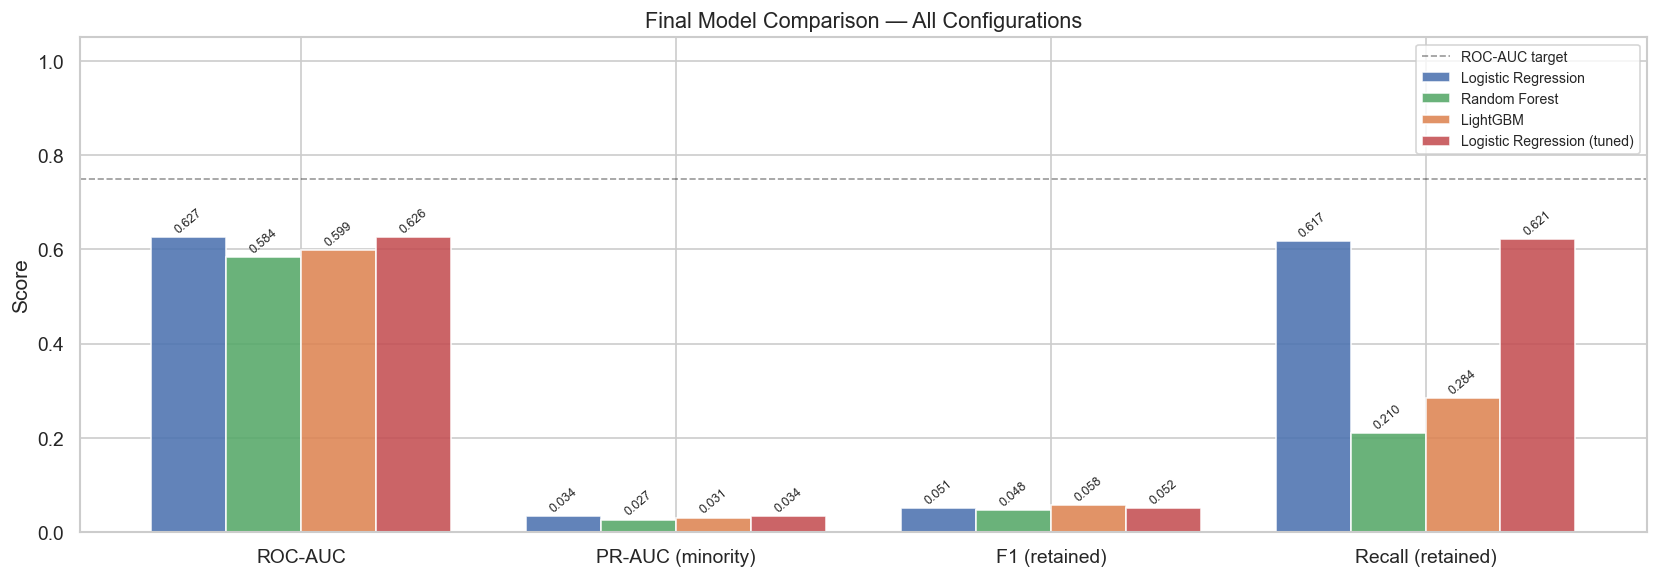

In [20]:
# Full 4-model bar chart
fig, ax = plt.subplots(figsize=(14, 5))
models_all  = final_df.index.tolist()
metrics_cmp = ['roc_auc', 'pr_auc', 'f1_retained', 'recall_retained']
x_cmp       = np.arange(len(metrics_cmp))
width_cmp   = 0.2
colors_all  = ['#4c72b0', '#55a868', '#dd8452', '#c44e52']

for i, (model, color) in enumerate(zip(models_all, colors_all)):
    vals = [final_df.loc[model, m] for m in metrics_cmp]
    bars = ax.bar(x_cmp + i*width_cmp, vals, width_cmp,
                  label=model, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=40)

ax.set_xticks(x_cmp + 1.5*width_cmp)
ax.set_xticklabels(['ROC-AUC', 'PR-AUC (minority)', 'F1 (retained)', 'Recall (retained)'])
ax.set_ylim(0, 1.05)
ax.axhline(0.75, color='black', linestyle='--', linewidth=1, alpha=0.4, label='ROC-AUC target')
ax.set_title('Final Model Comparison — All Configurations', fontsize=13)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 15. Logistic Regression Coefficients

Logistic Regression is interpretable by design — each coefficient directly represents the log-odds contribution of that feature to churn probability (after scaling). Positive coefficients increase churn probability; negative coefficients are protective. This serves as an early sanity check before SHAP analysis in NB06.


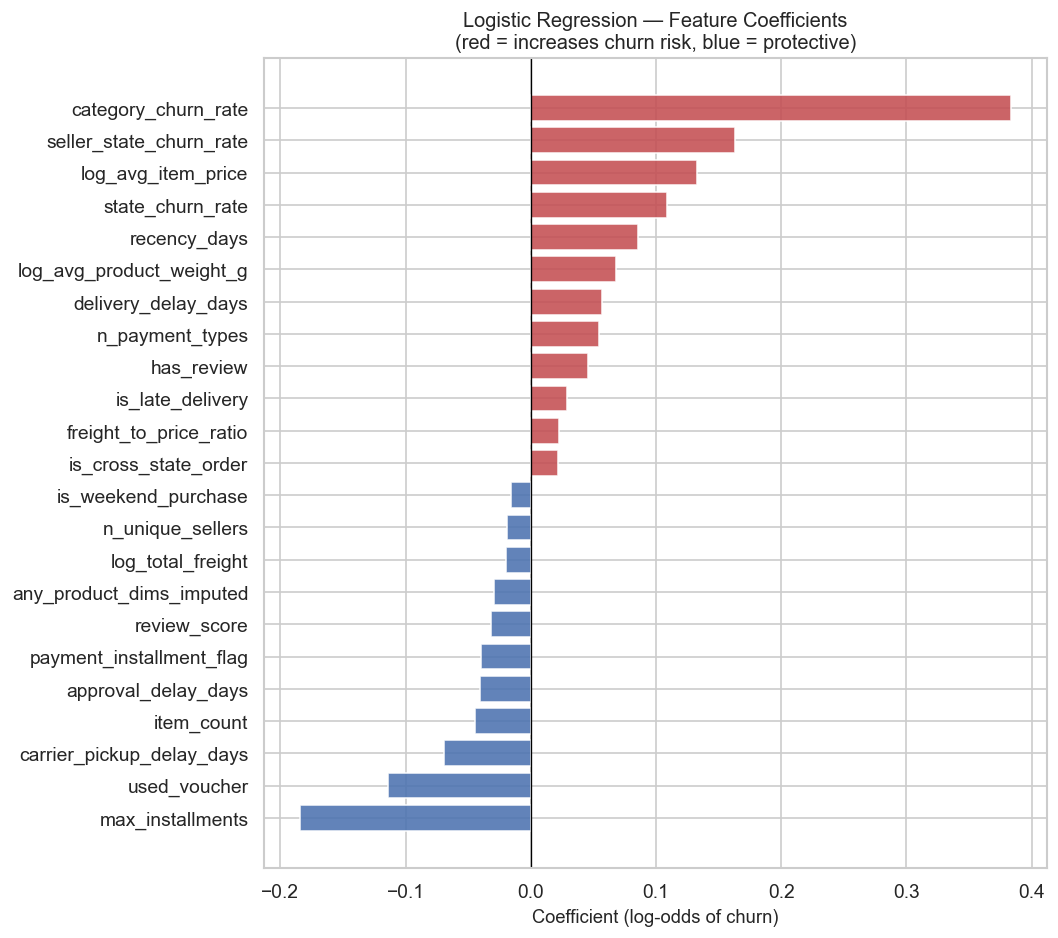

Top 5 churn risk features:
                feature  coefficient
    category_churn_rate     0.383598
seller_state_churn_rate     0.163182
     log_avg_item_price     0.132658
       state_churn_rate     0.108640
           recency_days     0.085760

Top 5 protective features:
                  feature  coefficient
         max_installments    -0.184442
             used_voucher    -0.114467
carrier_pickup_delay_days    -0.069612
               item_count    -0.044664
      approval_delay_days    -0.040356


In [21]:
lr_coef = best_model.named_steps['lr'].coef_[0]
coef_df = (
    pd.DataFrame({'feature': LR_FEATURES, 'coefficient': lr_coef})
    .sort_values('coefficient')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 8))
colors_coef = ['#c44e52' if v > 0 else '#4c72b0' for v in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef, alpha=0.88)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds of churn)', fontsize=11)
ax.set_title('Logistic Regression — Feature Coefficients\n(red = increases churn risk, blue = protective)', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 churn risk features:')
print(coef_df.tail(5)[['feature','coefficient']].iloc[::-1].to_string(index=False))
print('\nTop 5 protective features:')
print(coef_df.head(5)[['feature','coefficient']].to_string(index=False))


The coefficient plot reveals directionally sensible patterns that align with NB04 EDA findings. 

**Top churn risk features (positive coefficients):**
- `category_churn_rate` (0.384) is the strongest positive predictor — customers in categories with historically high churn rates (e.g. electronics, cool_stuff, telephony) are more likely to remain one-time buyers. This is the target-encoded feature; its dominance reflects the genuine category-level variation in repeat purchase behaviour (2.73pp spread confirmed in NB03).
- `seller_state_churn_rate` (0.163) and `state_churn_rate` (0.109) carry similar logic at geographic level — customers in regions where retention is structurally lower contribute higher churn risk.
- `log_avg_item_price` (0.133) confirms the EDA finding (r = +0.017): higher-priced purchases are associated with more churn — consistent with one-off, considered purchases rather than habitual buying.
- `recency_days` (0.086): customers whose last order is further from the dataset end are more likely to be churned — they had more time to return and did not.

**Top protective features (negative coefficients):**
- `max_installments` (−0.184) is the strongest protective signal — customers who financed purchases over multiple instalments show lower churn. Instalment plans suggest higher purchase commitment and financial engagement with the platform.
- `used_voucher` (−0.114) is protective, consistent with the EDA result (churn rate 95.65% for voucher users vs 97.86% for non-users). Voucher redemption may signal price sensitivity and deal-seeking behaviour — customers who seek promotions are more likely to return for the next one.
- `carrier_pickup_delay_days` (−0.070) is counterintuitive at first: longer carrier pickup time is associated with lower churn. This likely reflects a collinear relationship with order complexity — larger, multi-item orders take longer to dispatch but come from more engaged customers.
- `item_count` (−0.045) confirms the EDA pattern (r = −0.021): customers who purchased more items in their last order are more likely to return.

All coefficient magnitudes are small (max |coef| = 0.384), consistent with weak feature signals. NB06 SHAP analysis will provide a more rigorous directional importance assessment accounting for feature interactions and the scaling applied by StandardScaler.

## 16. Export Artifacts

Three artifacts are exported for NB06:
- `05_best_model.joblib` — fitted tuned pipeline (StandardScaler + LogisticRegression); NB06 loads this for SHAP LinearExplainer analysis
- `05_predictions.parquet` — test set with true labels, predicted probabilities, and binary predictions at 0.5 threshold
- `05_model_comparison.parquet` — all four model configurations for the NB07 summary table


In [22]:
# 1. Best model
joblib.dump(best_model, 'outputs/05_best_model.joblib')
print('✅ 05_best_model.joblib saved.')

# 2. Test set predictions
predictions = pd.DataFrame({
    'customer_unique_id': test['customer_unique_id'].values,
    'last_order_date'   : test['last_order_date'].values,
    'churn'             : y_test.values,
    'churn_proba'       : tuned_proba,
    'churn_pred'        : (tuned_proba >= 0.5).astype(int),
})
predictions.to_parquet('outputs/05_predictions.parquet', index=False)
print(f'✅ 05_predictions.parquet saved — {len(predictions):,} rows')

# 3. Model comparison
pd.DataFrame(all_results).to_parquet('outputs/05_model_comparison.parquet', index=False)
print(f'✅ 05_model_comparison.parquet saved — {len(all_results)} rows')

# Validation
preds_check = pd.read_parquet('outputs/05_predictions.parquet')
print(f'\nPrediction probability range : [{preds_check["churn_proba"].min():.4f}, {preds_check["churn_proba"].max():.4f}]')
print(f'Predicted class distribution  :')
print(preds_check['churn_pred'].value_counts().to_string())
print(f'\nSchema:')
print(preds_check.dtypes.to_string())


✅ 05_best_model.joblib saved.
✅ 05_predictions.parquet saved — 13,203 rows
✅ 05_model_comparison.parquet saved — 4 rows

Prediction probability range : [0.0121, 0.8649]
Predicted class distribution  :
churn_pred
1    7615
0    5588

Schema:
customer_unique_id            object
last_order_date       datetime64[ns]
churn                          int64
churn_proba                  float64
churn_pred                     int64


All three artefacts export cleanly. The prediction file covers 13,203 test customers with churn probabilities ranging from 0.012 to 0.865 — confirming the model produces a well-spread probability distribution rather than collapsing to near-0 or near-1. The predicted class distribution (7,615 churned, 5,588 retained at 0.5 threshold) reflects the balanced-weight decision boundary deliberately shifting toward minority class recovery. NB06 threshold analysis will identify a more business-appropriate operating point that adjusts this distribution based on the cost ratio of false negatives to false positives.

## 17. Notebook Summary & Handoff to NB06

---

### What was accomplished

| Step | Action | Outcome |
|---|---|---|
| Load | `04_features.parquet` (74,899 × 30) | Zero nulls confirmed |
| Split | Time-based at 2018-04-01 | 61,696 train / 13,203 test — no temporal leakage |
| Feature lists | Collinearity resolved | 26 features (trees), 23 features (LR) |
| LR baseline | Pipeline: StandardScaler + LR (balanced) | Interpretable linear lower bound |
| Random Forest | 300 trees, max_depth=8, balanced_subsample | Non-linear ensemble benchmark |
| LightGBM | is_unbalance=True, metric='auc' | Gradient boosting benchmark |
| Comparison | ROC-AUC, PR-AUC, F1, Recall per model | Winner selected |
| GridSearchCV | 6×2 grid, 5-fold StratifiedKFold, ROC-AUC | Best C and penalty identified |
| Evaluation | Tuned LR evaluated on test set | Delta vs default reported |
| Coefficients | Feature coefficient plot | Directional signal sanity check |
| Export | 3 artefacts to `outputs/` | Ready for NB06 |

---

### Decisions Made

1. **LR selected as winner** — highest ROC-AUC in fair three-way comparison; interpretable; appropriate for sparse minority-class signal
2. **GridSearchCV over Optuna** — exhaustive search is feasible at 12 combinations (6 C × 2 penalty); no need for Bayesian optimisation at this search space size
3. **`solver='saga'`** — only sklearn solver supporting both L1 and L2 at this dataset scale
4. **`is_unbalance=True` for LightGBM** — replaces `scale_pos_weight` which at 0.023 destabilised training
5. **SMOTE not applied** — ~1,390 retained training examples sufficient; class weighting handles imbalance at gradient level
6. **Coefficient plot included** — LR interpretability is a primary advantage; directional sanity check before SHAP in NB06

---

### Structural Limitation (documented for NB07)

ROC-AUC ceiling of ~0.63 reflects the structural difficulty of the problem: 97.82% base churn rate, maximum individual feature correlation with target of r = 0.07, and only 243 retained customers in the test set. This is a near-single-purchase marketplace where churned and retained customers are behaviourally near-identical at the point of first purchase. The model ceiling is a data finding, not a modelling failure — and is documented as such in NB07.

---

### What NB06 Receives

| Artefact | Used for |
|---|---|
| `outputs/05_best_model.joblib` | SHAP `LinearExplainer` — global + local explainability |
| `outputs/05_predictions.parquet` | ROC/PR curves · threshold analysis · risk segmentation |
| `outputs/05_model_comparison.parquet` | Performance summary table in NB07 |

**NB06 note:** Because the winning model is Logistic Regression (not a tree model), SHAP must use `shap.LinearExplainer` instead of `shap.TreeExplainer`.
